In [151]:
import warnings
warnings.filterwarnings ("ignore")

In [152]:
import pandas as P

In [153]:
D = P.read_csv ("CCP.csv")

In [154]:
print(D.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [155]:
print(D.shape)

(7043, 21)


In [156]:
print(D.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [157]:
from sklearn.preprocessing import LabelEncoder

In [158]:
LE = LabelEncoder ()

In [159]:
D["customerID"] = LE.fit_transform (D["customerID"])
D["gender"] = LE.fit_transform (D["gender"])
D["Partner"] = LE.fit_transform (D["Partner"])
D["Dependents"] = LE.fit_transform (D["Dependents"])
D["PhoneService"] = LE.fit_transform (D["PhoneService"])
D["MultipleLines"] = LE.fit_transform (D["MultipleLines"])
D["InternetService"] = LE.fit_transform (D["InternetService"])
D["OnlineSecurity"] = LE.fit_transform (D["OnlineSecurity"])
D["OnlineBackup"] = LE.fit_transform (D["OnlineBackup"])
D["DeviceProtection"] = LE.fit_transform (D["DeviceProtection"])
D["TechSupport"] = LE.fit_transform (D["TechSupport"])
D["StreamingTV"] = LE.fit_transform (D["StreamingTV"])
D["StreamingMovies"] = LE.fit_transform (D["StreamingMovies"])
D["Contract"] = LE.fit_transform (D["Contract"])
D["PaperlessBilling"] = LE.fit_transform (D["PaperlessBilling"])
D["PaymentMethod"] = LE.fit_transform (D["PaymentMethod"])
D["TotalCharges"] = LE.fit_transform (D["TotalCharges"])
D["Churn"] = LE.fit_transform (D["Churn"])

In [160]:
print(D.dtypes)

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object


In [161]:
X = D.drop (["Churn"] , axis = 1)
Y = D["Churn"]

In [162]:
NULL_X = X.isnull ().sum ()
print(NULL_X)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [163]:
NULL_Y = Y.isnull ().sum ()
print(NULL_Y)

0


In [164]:
from sklearn.model_selection import train_test_split

In [165]:
X_Train , X_Test , Y_Train , Y_Test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)
print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(5634, 20)
(1409, 20)
(5634,)
(1409,)


In [166]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

In [167]:
M_1 = LinearRegression ()
M_2 = RandomForestClassifier ()
F_1 = M_1.fit (X_Train , Y_Train)
F_2 = M_2.fit (X_Train , Y_Train)
print(M_1)
print(M_2)
print(F_1)
print(F_2)

LinearRegression()
RandomForestClassifier()
LinearRegression()
RandomForestClassifier()


In [168]:
PRE_1 = F_1.predict (X_Test)
PRE_2 = F_2.predict (X_Test)
print(PRE_1)
print(PRE_2)

[ 0.5282054   0.15581286 -0.09853503 ...  0.08283638  0.03072437
  0.44818254]
[1 0 0 ... 0 0 0]


In [169]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
import numpy as N
R2_1 = r2_score (Y_Test , PRE_1)
R2_2 = r2_score (Y_Test , PRE_2)
print(R2_1 * 100 , "%")
print(R2_2 * 100 , "%")
print("\n")
MAE_1 = mean_absolute_error (Y_Test , PRE_1)
MAE_2 = mean_absolute_error (Y_Test , PRE_2)
print(MAE_1)
print(MAE_2)
print("\n")
MSE_1 = mean_squared_error (Y_Test , PRE_1)
MSE_2 = mean_squared_error (Y_Test , PRE_2)
print(MSE_1)
print(MSE_2)
print("\n")
RMSE_1 = N.sqrt (MSE_1)
RMSE_2 = N.sqrt (MSE_2)
print(RMSE_1)
print(RMSE_2)
print("\n")


29.32909044601385 %
-3.9171592120653687 %


0.30672755840650173
0.20227111426543648


0.13755845261767863
0.20227111426543648


0.3708887334736371
0.44974561061275126




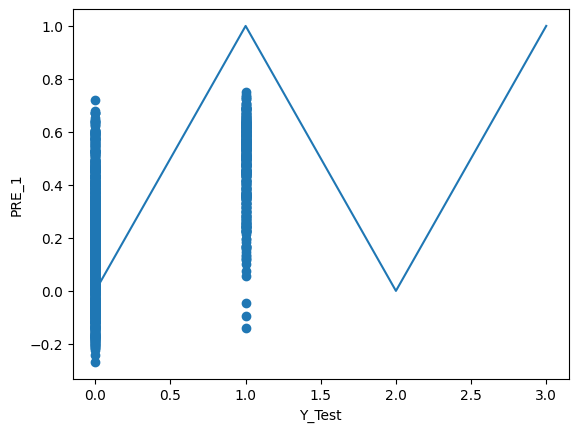

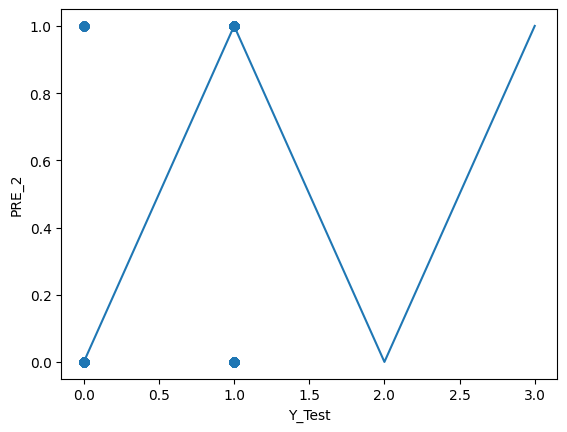

In [170]:
import matplotlib.pyplot as PLOT
PLOT.scatter (Y_Test , PRE_1)
PLOT.plot ([Y_Test.min () , Y_Test.max () , Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE_1")
PLOT.show ()
print("\n")
PLOT.scatter (Y_Test , PRE_2)
PLOT.plot ([Y_Test.min () , Y_Test.max () , Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE_2")
PLOT.show ()

In [171]:
PRE_T_1 = F_1.predict ([[1 , 0 , 1 , 0 , 5 , 1 , 0 , 2 , 0 , 1 , 0 , 0 , 1 , 1 , 0 , 1 , 1 , 0 , 80.5 , 400]])
PRE_T_2 = F_2.predict ([[1 , 0 , 1 , 0 , 5 , 1 , 0 , 2 , 0 , 1 , 0 , 0 , 1 , 1 , 0 , 1 , 1 , 0 , 80.5 , 400]])
print(PRE_T_1)
print(PRE_T_2)

[0.50439323]
[0]


In [172]:
def CT_1 () :
  if PRE_T_1 == 1 :
    return "Customer Will Go"
  elif PRE_T_1 < 1 and PRE_T_1 > 0 :
    return "Customer Will Think"
  else :
    return "Customer Will Not Go"
print(CT_1 ())
print("\n")
def CT_2 () :
  if PRE_T_2 == 1 :
    return "Customer Will Go"
  elif PRE_T_2 < 1 and PRE_T_2 > 0 :
    return "Customer Will Think"
  else :
    return "Customer Will Not Go"
print(CT_2 ())

Customer Will Think


Customer Will Not Go
